# Waterfilling Algorithm: Capacity-Aware Network Optimization
This notebook provides a comprehensive environment for testing and visualizing the waterfilling algorithm across various network architectures. 

### Key Features:
- **Stochastic Testing**: Rigorous evaluation using Gaussian noise averaging.
- **Architecture Benchmarks**: Comparing Opera, Shale, and Sirius.
- **Hybrid Genetic Algorithm**: Traffic-aware topology evolution optimizing for Shannon Capacity.
- **Opera Model**: Implements a '1 Hop = 1 Timeslot' penalty and node-weight normalization for fair comparison.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import os
from Waterfilling_Alg import waterfilling
from Shale_Alg import RR2, RR2_path, spray_short
from Common_Alg import generate_random_latin_square
from Sirius import generate_full_system
from AI_Topology import evolve_topology, generate_random_topology, calculate_aspl
from Opera_Alg import find_optimal_path_broken_racks, find_path_2d
from Traffic_Benchmarks import calculate_topology_capacity, generate_uniform_traffic, generate_skewed_traffic, generate_hotspot_traffic

# Ensure plots directory exists
if not os.path.exists('plots'):
    os.makedirs('plots')

--- Simple 8x8 Latin Square ---
[[1, 2, 3, 4, 5, 6, 7, 8], [2, 3, 4, 5, 6, 7, 8, 1], [3, 4, 5, 6, 7, 8, 1, 2], [4, 5, 6, 7, 8, 1, 2, 3], [5, 6, 7, 8, 1, 2, 3, 4], [6, 7, 8, 1, 2, 3, 4, 5], [7, 8, 1, 2, 3, 4, 5, 6], [8, 1, 2, 3, 4, 5, 6, 7]]
--- Randomized 8x8 Latin Square ---
[[8, 6, 1, 2, 5, 7, 4, 3], [4, 1, 5, 8, 7, 3, 6, 2], [6, 5, 7, 4, 3, 2, 1, 8], [3, 8, 4, 7, 6, 1, 2, 5], [2, 4, 6, 3, 1, 5, 8, 7], [5, 3, 2, 1, 8, 4, 7, 6], [1, 7, 3, 6, 2, 8, 5, 4], [7, 2, 8, 5, 4, 6, 3, 1]]
[[0, 1], [1, 2], [3, 0]]
[[1, 0], [2, 1], [0, 3]]
### Optimized Functions ###
RR1(4):
[[1, 2, 3, 4], [2, 3, 4, 1], [3, 4, 1, 2], [4, 1, 2, 3]]
RR2(3, 2):
[[1, 2, 3, 6], [0, 4, 2, 7], [5, 0, 1, 8], [4, 5, 6, 0], [3, 1, 7, 5], [2, 3, 8, 4], [8, 7, 0, 3], [6, 8, 4, 1], [7, 6, 5, 2]]

---

RR3(3, 2, 1):
[[1, 2, 3, 6], [0, 4, 2, 7], [5, 0, 1, 8], [4, 5, 6, 0], [3, 1, 7, 5], [2, 3, 8, 4], [8, 7, 0, 3], [6, 8, 4, 1], [7, 6, 5, 2]]

---

RR3(4, 3, 2):
[[5, 6, 7, 9, 10, 11, 13, 14, 15, 17, 18, 19, 20, 24, 28, 33, 34, 

In [2]:
def run_rigorous_waterfilling(base_noise, total_power, iterations=500, noise_std=1.0):
    """
    Runs the waterfilling algorithm multiple times with added Gaussian noise 
    and returns the average and standard deviation of allocations.
    """
    base_noise = np.array(base_noise)
    all_allocations = []
    
    for _ in range(iterations):
        stochastic_noise = np.maximum(base_noise + np.random.normal(0, noise_std, base_noise.shape), 0.1)
        alloc = waterfilling(stochastic_noise, total_power)
        all_allocations.append(alloc)
        
    return np.mean(all_allocations, axis=0), np.std(all_allocations, axis=0)

def visualize_waterfilling(channels, total_power, title="Waterfilling Results", filename=None, yerr=None):
    """
    Visualizes power allocation. 
    Supports error bars for rigorous testing and recursion for multi-timeslot data.
    """
    channels = np.array(channels)
    if channels.ndim == 2:
        num_timeslots = channels.shape[0]
        powers = [total_power] * num_timeslots if np.isscalar(total_power) else total_power
        for t in range(num_timeslots):
            ts_suffix = f"_ts{t}"
            ts_filename = f"{filename}{ts_suffix}" if filename else None
            ts_yerr = yerr[t] if yerr is not None else None
            visualize_waterfilling(channels[t], powers[t], title=f"{title} - TS{t}", filename=ts_filename, yerr=ts_yerr)
        return

    allocation = waterfilling(channels, total_power)
    n = len(channels)
    indices = np.arange(n)
    active_mask = allocation > 1e-9
    bottleneck_mask = ~active_mask
    water_level = np.mean(channels[active_mask] + allocation[active_mask]) if np.any(active_mask) else 0

    plt.figure(figsize=(10, 6))
    plt.bar(indices[active_mask], channels[active_mask], label='Noise', color='lightgray', edgecolor='black')
    if np.any(bottleneck_mask):
        plt.bar(indices[bottleneck_mask], channels[bottleneck_mask], label='Bottleneck', color='salmon', edgecolor='black', hatch='//')
    plt.bar(indices[active_mask], allocation[active_mask], bottom=channels[active_mask], 
            label='Power', color='skyblue', edgecolor='black', yerr=yerr[active_mask] if yerr is not None else None, capsize=5)
    plt.axhline(y=water_level, color='blue', linestyle='--', label=f'Water Level ({water_level:.2f})')
    plt.title(title)
    plt.xlabel('Link Index')
    plt.ylabel('Level')
    plt.legend()
    plt.tight_layout()
    if filename:
        if filename.startswith('plots/'):
            save_path = filename
        else:
            save_path = f"plots/{filename}"
            
        if not save_path.lower().endswith('.png'): 
            save_path += '.png'
        
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
    plt.show()

## 1. Opera Context
Static allocation on weighted racks.

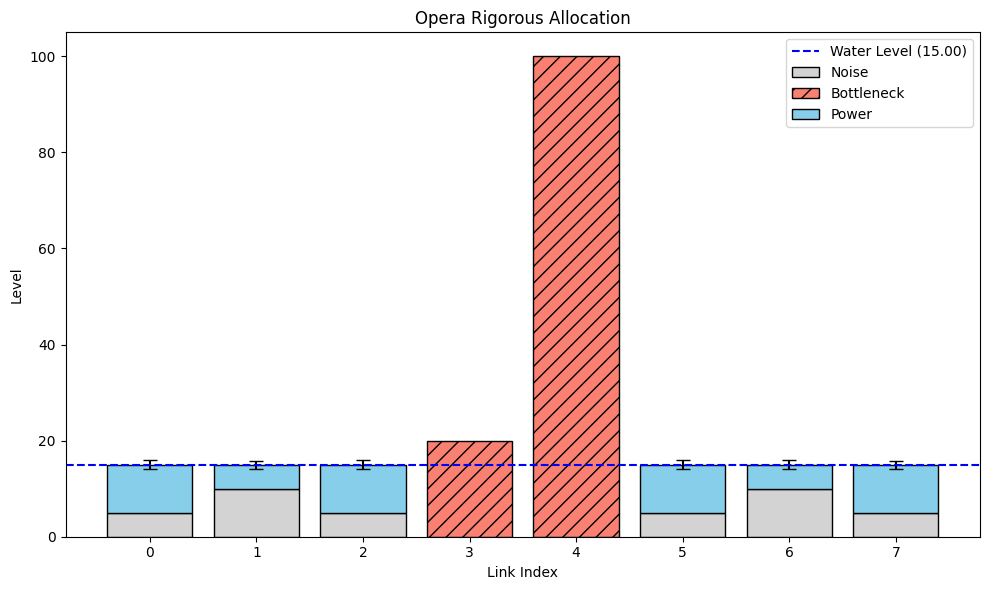

In [3]:
rack_weights = [5, 10, 5, 20, 100, 5, 10, 5]
total_power = 50
avg_p, std_p = run_rigorous_waterfilling(rack_weights, total_power)
visualize_waterfilling(rack_weights, total_power, title="Opera Rigorous Allocation", filename="opera_rigorous", yerr=std_p)

## 2. Shale Context
Allocation on regular expander-like topologies.

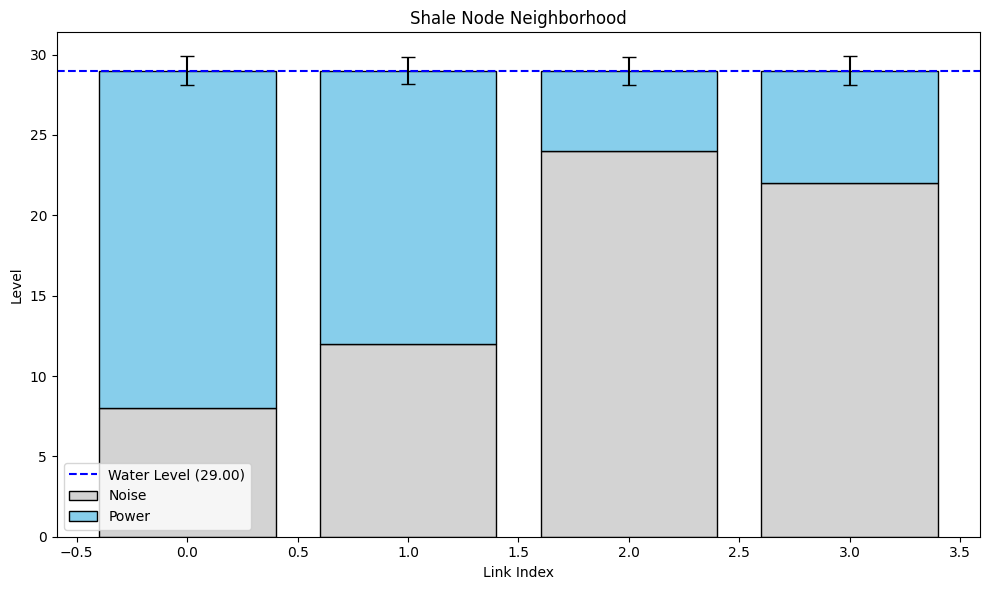

In [4]:
num_nodes, degree = 10, 4
shale_links = generate_random_topology(num_nodes, degree)
link_noise = [random.randint(5, 25) for _ in range(degree)] # Sample links for node 0
avg_p, std_p = run_rigorous_waterfilling(link_noise, 50)
visualize_waterfilling(link_noise, 50, title="Shale Node Neighborhood", filename="shale_rigorous", yerr=std_p)

## 3. Sirius Context (Time-Slotted)
Dynamic power allocation across multiple reconfigurable slots.

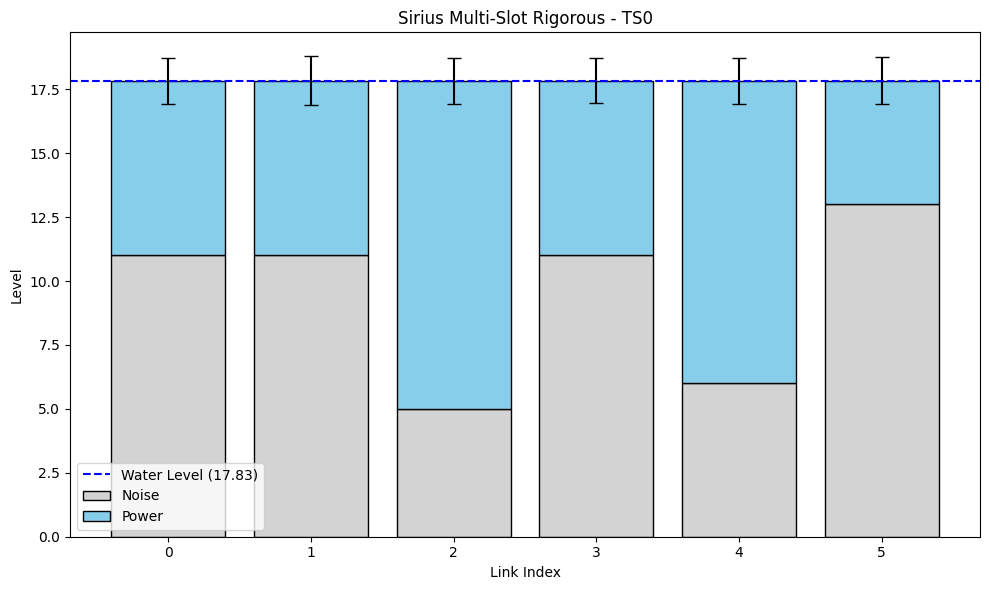

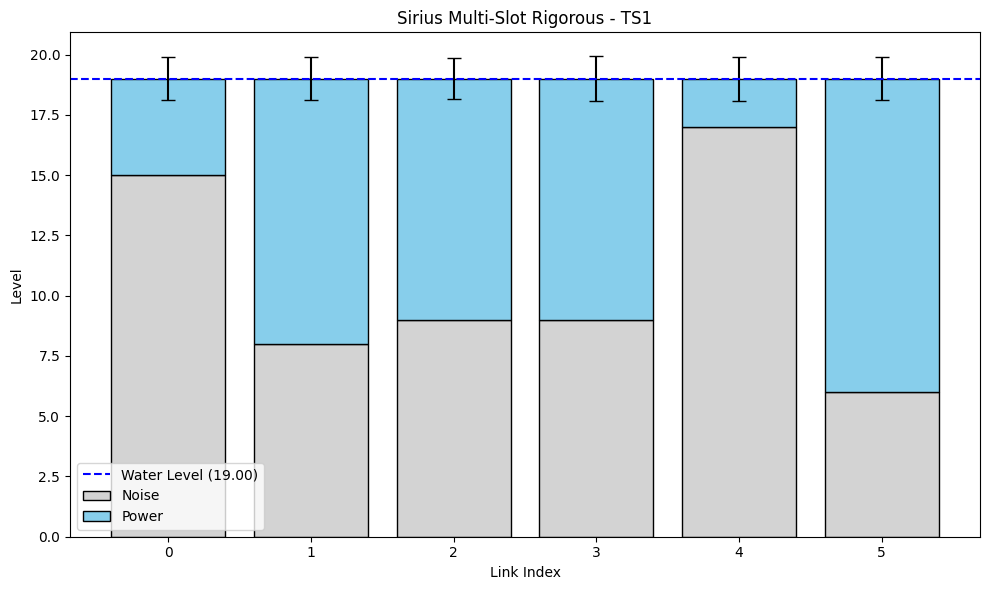

In [5]:
As, Ws, P_mat = generate_full_system(wavelengths=2, ports=2, nodes=6)
channels = [[random.randint(5, 20) for _ in range(6)] for _ in Ws]
sirius_stds = [run_rigorous_waterfilling(ch, 50)[1] for ch in channels]
visualize_waterfilling(channels, 50, title="Sirius Multi-Slot Rigorous", filename="sirius_rigorous", yerr=np.array(sirius_stds))

## 4. Hybrid Genetic Algorithm Evolution
Evolving a topology with a **Frozen Ring Backbone** optimizing for **Skewed Traffic Capacity**.

In [6]:
num_nodes = 10
target_degree = 4

# Define a Ring Backbone (Degree 2)
ring_backbone = [[] for _ in range(num_nodes)]
for i in range(num_nodes):
    ring_backbone[i].extend([(i + 1) % num_nodes, (i - 1) % num_nodes])

print("Starting Capacity-Aware Evolution...")
best_adj = evolve_topology(num_nodes, target_degree, generations=20, 
                            traffic_type="skewed", frozen_backbone=ring_backbone)

traffic = generate_skewed_traffic(num_nodes)
final_cap = calculate_topology_capacity(best_adj, traffic, total_power=50)
print(f"Evolution Complete. Final Shannon Capacity: {final_cap:.4f}")

Starting Capacity-Aware Evolution...
AI Evolving Topology (PyGAD) (N=10, D=4, Traffic=skewed)...
Evolution Complete. Best Fitness: 1.2970
Best ASPL: 1.6889 | Final Capacity: 3.0099
Evolution Complete. Final Shannon Capacity: 3.0099


## 5. Grand Architecture Comparison
Performance benchmark of all 4 architectures on Skewed Traffic using Shannon Capacity with standardized power levels.

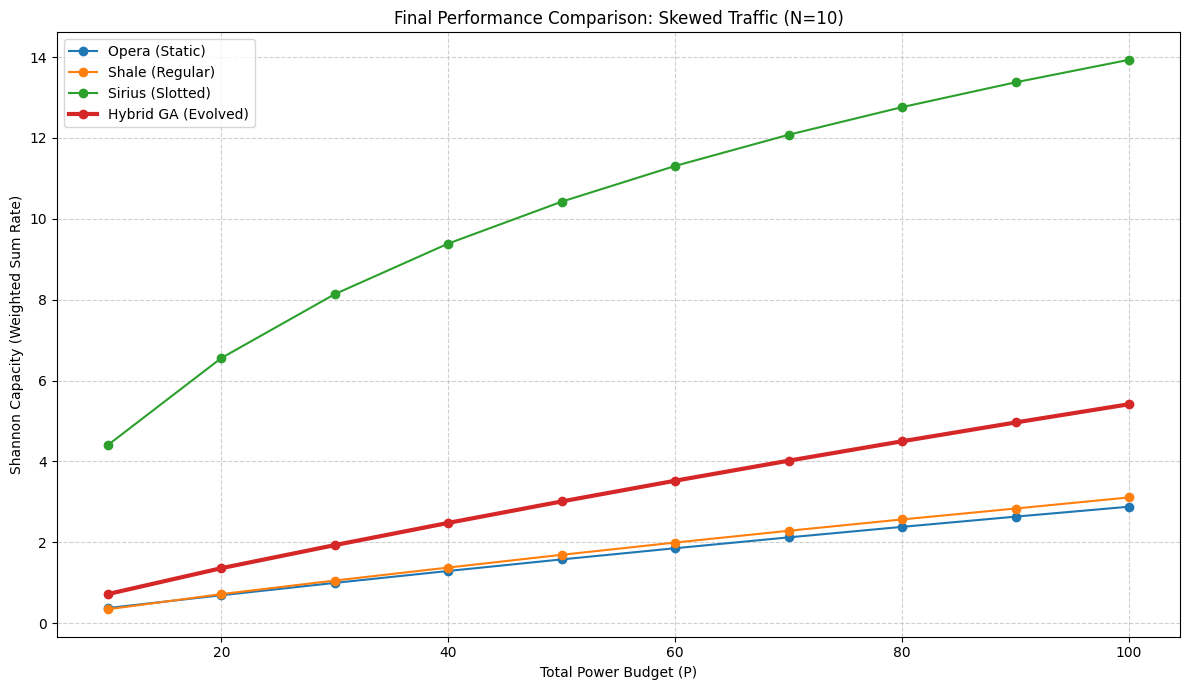

In [7]:
num_nodes = 10
target_degree = 4
power_levels = np.linspace(10, 100, 10)
traffic = generate_skewed_traffic(num_nodes)

# 1. Opera (Static Latin Square)
opera_raw = generate_random_latin_square(num_nodes)
opera_adj = [[(v - 1) % num_nodes for v in row[:target_degree]] for row in opera_raw]

# 2. Shale (Regular Topology)
shale_adj = generate_random_topology(num_nodes, target_degree)

# 3. Sirius (Time-Slotted A1 Matrix)
As, _, _ = generate_full_system(2, 2, num_nodes)
sirius_adj = [[(v - 1) % num_nodes for v in row] for row in As[0]]

architectures = {
    "Opera (Static)": opera_adj,
    "Shale (Regular)": shale_adj,
    "Sirius (Slotted)": sirius_adj,
    "Hybrid GA (Evolved)": best_adj
}

results = {name: [] for name in architectures}
for name, adj in architectures.items():
    arch_type = "opera" if "Opera" in name else None
    for P in power_levels:
        results[name].append(calculate_topology_capacity(adj, traffic, total_power=P, architecture_type=arch_type))

plt.figure(figsize=(12, 7))
for name, capacities in results.items():
    lw = 3 if "GA" in name else 1.5
    plt.plot(power_levels, capacities, marker='o', label=name, linewidth=lw)

plt.title(f"Final Performance Comparison: Skewed Traffic (N={num_nodes})")
plt.xlabel("Total Power Budget (P)")
plt.ylabel("Shannon Capacity (Weighted Sum Rate)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("plots/final_comparison.png")
plt.show()